In [11]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict


In [12]:
class BMIState(TypedDict):
    weight: float
    height: float
    bmi: float

In [13]:
def calculate_bmi(state: BMIState) -> BMIState:
    # Calculate BMI using the formula: BMI = weight (kg) / (height (m))^2
    state['bmi'] = state['weight'] / (state['height'] ** 2)
    return state

In [14]:
#define the graph 
graph=StateGraph(BMIState)
#add node into the graph
graph.add_node("Calculate_BMI",calculate_bmi)

#Connect the nodes in the graph
graph.add_edge(START,"Calculate_BMI")
graph.add_edge("Calculate_BMI",END)

#compile the graph
workflow=graph.compile()
initial_state=BMIState(weight=70,height=1.75,bmi=0)
workflow.invoke(initial_state)


{'weight': 70, 'height': 1.75, 'bmi': 22.857142857142858}

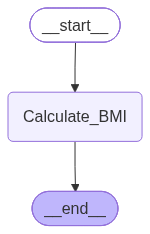

In [18]:
from IPython.display import Image, display

display(Image(data=workflow.get_graph().draw_mermaid_png()))